
# FSC ↔ tinyRNN pipeline

Two independent ways of extracting a **minimal, interpretable model of decision-making**
from the same behavioral data:

1. **Finite State Controller (FSC)** — Nicoletti & Celani, *"Decoding behavior with
   minimal and interpretable agent models"* (2026). A discrete-state controller fit by
   MAPSO (particle-swarm) + gradient descent.
   Code: [`FSC-inference-MAPSO`](https://github.com/giorgionicoletti/FSC-inference-MAPSO)
2. **tinyRNN** — Ji-An, Benna & Mattar, *"Discovering cognitive strategies with tiny
   recurrent neural networks"* (Nature, 2025). A small GRU trained with the paper's
   official nested cross-validation procedure to find the smallest RNN that explains
   the behavior.
   Code: [`tinyRNN`](https://github.com/cgc/tinyRNN)

## A note on fidelity
Both repos are vendored (git-cloned) rather than reimplemented, and the training /
inference calls below follow the authors' own example notebooks / experiment scripts
as closely as possible, so that nothing about *how* the models are fit is invented here.


- **The "free experiments" section (Section 4)** is analysis code we write ourselves.
  Where it touches the FSC's internal dynamics (the belief-state decoder), it is a
  direct implementation of the same forward-filtering recursion the library itself
  computes inside `inference.loss` (see Section 4.1), not a new model.

## Reproducibility — how someone else runs this
The two upstream repos are **not** committed to this project's repo; Section 0 `git clone`s
them fresh (`--depth 1`) into `FSC-inference-MAPSO/` and `tinyRNN/`. So a fresh checkout of
this project is just the notebook, the `wsls_actions_observations.npz` data, and the
`fitted_models/` artifacts — you run Section 0 once and the libraries appear locally.

The **only** modifications made to those cloned libraries are two automated patches that
Section 0 applies itself (idempotently) each run:
1. `path_settings.py` — replace the upstream hardcoded Windows `MODEL_SAVE_PATH` with a
   local relative path, so the notebook is portable.
2. `datasets/SimpleDataset.py` — a one-line upstream bug fix for variable-length sessions.

Because both patches live in the notebook (not hand-edits made outside it), a fresh clone +
run reproduces them exactly — nothing about the fitted models depends on manual edits.
The `fitted_models/` directory ships the already-fit results (FSC sweep + the full RNN
nested-CV) so you can explore Sections 2.3/3.3 onward without re-running the (slow) fits;
delete it (or flip the `FORCE_*` toggles) to regenerate from scratch.

## Requirements
Python ≥3.10, and (installed in Section 0): `torch`, `numpy`, `scipy`, `pandas`,
`scikit-learn`, `statsmodels`, `numba`, `networkx`, `joblib`, `matplotlib`, `tqdm`.
tinyRNN training is CPU-friendly for small hidden sizes but will be much faster on GPU
for larger sweeps / real datasets — hence this notebook is meant to be run on your own
machine or Colab rather than in-chat.


## 0. Setup — clone repos, install dependencies, patch paths

In [2]:

# Clone both repos (skips if already present, e.g. re-running this cell)
import os, subprocess

REPOS = {
    "FSC-inference-MAPSO": "https://github.com/giorgionicoletti/FSC-inference-MAPSO.git",
    "tinyRNN": "https://github.com/cgc/tinyRNN.git",
}
for name, url in REPOS.items():
    if not os.path.isdir(name):
        subprocess.run(["git", "clone", "--depth", "1", url, name], check=True)
    else:
        print(f"{name} already present, skipping clone.")


FSC-inference-MAPSO already present, skipping clone.
tinyRNN already present, skipping clone.


In [3]:

# Install dependencies (skip/comment out any you already have, e.g. torch with CUDA)
import sys
%pip install -q torch numpy scipy pandas scikit-learn statsmodels numba networkx joblib matplotlib tqdm


Note: you may need to restart the kernel to use updated packages.


In [4]:

# --- Patch 1: point tinyRNN's MODEL_SAVE_PATH at a local relative folder -----------
# The repo ships with a hardcoded Windows path (D:\...); we override it so the
# notebook is portable. This is exactly the kind of thing path_settings.py is meant
# for (the file is literally called "user-specific settings").
path_settings_file = "tinyRNN/path_settings.py"
with open(path_settings_file) as f:
    content = f.read()
content = content.replace(
    r"MODEL_SAVE_PATH = Path('D:\\cognitive_dynamics\\saved_model')",
    "MODEL_SAVE_PATH = Path('./files/saved_model')",
)
with open(path_settings_file, "w") as f:
    f.write(content)
print("Patched tinyRNN/path_settings.py -> MODEL_SAVE_PATH = ./files/saved_model")


Patched tinyRNN/path_settings.py -> MODEL_SAVE_PATH = ./files/saved_model


In [5]:

# --- Patch 2: upstream bug fix in SimpleDataset.py ---------------------------------
# SimpleDataset._behav_to_tensor computes `invalid = value == -1` on a per-session
# array of length `trial_count`, then does `mask[b, invalid] = 0` where `mask`'s
# second axis has length `trial_num` (the length of the LONGEST session, used for
# padding). Whenever a session is shorter than the longest one (i.e. real behavioral
# data with variable trial counts per session), the boolean array length doesn't
# match the array being indexed and this throws an IndexError.
# Fix: index with `idxs[invalid]` (idxs = np.arange(trial_count)) instead of `invalid`
# directly, so the boolean mask is applied to the correct sub-range.
simple_dataset_file = "tinyRNN/datasets/SimpleDataset.py"
with open(simple_dataset_file) as f:
    content = f.read()
buggy = "                invalid = value == -1\n                mask[b, invalid] = 0"
fixed = "                invalid = value == -1\n                mask[b, idxs[invalid]] = 0"
if buggy in content:
    content = content.replace(buggy, fixed)
    with open(simple_dataset_file, "w") as f:
        f.write(content)
    print("Patched tinyRNN/datasets/SimpleDataset.py (variable-length-session bug fix).")
elif fixed in content:
    print("SimpleDataset.py already patched.")
else:
    print("WARNING: expected code not found — SimpleDataset.py may have changed upstream. "
          "If you hit an IndexError in Section 3, look for the 'invalid'/'mask' lines "
          "in datasets/SimpleDataset.py and apply the same fix by hand.")


SimpleDataset.py already patched.


In [6]:
import sys, os
import pickle
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

# --- Both repos define top-level modules with the SAME NAME ('utils', and for FSC
# also 'parametrizations'/'MAPSO'/'environments'/'DiscreteObs'). They can't both sit
# on sys.path at the same time without one shadowing the other, so we switch between
# them explicitly (using absolute paths, since cwd changes later when we `os.chdir`
# into tinyRNN in Section 3).
FSC_SRC = os.path.abspath("FSC-inference-MAPSO/src")
TINYRNN_ROOT = os.path.abspath("tinyRNN")
_COLLIDING_MODULE_NAMES = ("utils", "FSC", "MAPSO", "parametrizations", "environments", "DiscreteObs")

def _use_fsc_path():
    if TINYRNN_ROOT in sys.path:
        sys.path.remove(TINYRNN_ROOT)
    if FSC_SRC not in sys.path:
        sys.path.insert(0, FSC_SRC)
    for mod in list(sys.modules):
        if mod.split(".")[0] in _COLLIDING_MODULE_NAMES:
            del sys.modules[mod]

def _use_tinyrnn_path():
    if FSC_SRC in sys.path:
        sys.path.remove(FSC_SRC)
    if TINYRNN_ROOT not in sys.path:
        sys.path.insert(0, TINYRNN_ROOT)
    for mod in list(sys.modules):
        if mod.split(".")[0] in _COLLIDING_MODULE_NAMES:
            del sys.modules[mod]

_use_fsc_path()
import FSC as fsc_lib   # from FSC-inference-MAPSO

print("Imports OK")

Imports OK



## 1. Data input

**Canonical format used throughout this notebook:** a list of *sessions* (a session =
one continuous behavioral episode / recording block). Each session is a `dict`:

```python
{
    "actions":      [...],   # length-T sequence, one action per trial
    "observations": [...],   # length-T sequence, one observation per trial
    "reward":       [...],   # OPTIONAL, length-T sequence
}
```

Values can be ints, strings, or floats-that-are-really-categories — they get encoded
into integer indices in Section 1.2. Sessions can have **different lengths** (that's
the whole point of the bug fix in Section 0).

**This format is _ours_, not something either repo requires.** The two libraries want
*different* native formats (the FSC wants a list of `{"actions", "observations"}` dicts;
tinyRNN wants a dict of columns plus a little spec). This `sessions` list-of-dicts is just a
single convenient intake layer we chose; Sections 2 and 3 convert it into each repo's own
format. There are other ways to feed the data — this is simply a clean one.

Three ways to get your data into this format — **use whichever matches what you have**:
- **1.1a** — already have a list of dicts like the above (e.g. built from a pickle /
  your own loader) → skip straight to Section 1.2.
- **1.1b** — a long-format CSV: one row per trial, with a session-id column, an
  action column, an observation column, and (optionally) a reward column.
- **1.1c** — no real data yet → generates a small synthetic task so you can run the
  whole notebook end to end and sanity-check the pipeline before plugging in real data.

Only run **one** of 1.1a/1.1b/1.1c.


In [7]:
# --- 1.1a — Load the dataset ---------------------------------------------------------
# Pick which dataset to run the whole notebook on. Switching this ONE variable routes both
# the data loaded here AND the per-dataset model-save folders (Sections 2-3), so different
# datasets never overwrite each other's fitted models.
DATASET = "random_init"     # "original" | "det_init" | "random_init"
_DATASET_FILES = {
    "original":    "datasets/wsls_actions_observations.npz",
    "det_init":    "datasets/wsls_actions_observations_det_init.npz",
    "random_init": "datasets/wsls_actions_observations_random_init.npz",
}
DATA_PATH = _DATASET_FILES[DATASET]

# The current datasets are win-stay-lose-shift: actions in {-1,+1} (which option chosen),
# observations in {0,1} (the OUTCOME of that trial: 1=win, 0=lose). observation[t] is the
# result of action[t] and drives action[t+1] (win->stay, lose->shift). Convention note: the
# RNN predicts action[t] from strictly earlier trials; the FSC's likelihood conditions
# action[t] on observation[t] -- harmless here (action[t] is independent of observation[t]),
# but it matters on tasks where the observation is a pre-action stimulus.
raw = np.load(DATA_PATH)
raw_actions = raw["actions"]
raw_observations = raw["observations"]

N_SESSIONS_TO_USE = 1000    # cap: subsamples if the file has more sessions, uses all if fewer
n_total = raw_actions.shape[0]
n_use = n_total if N_SESSIONS_TO_USE is None else min(N_SESSIONS_TO_USE, n_total)
idx = np.arange(n_total) if n_use == n_total \
      else np.random.default_rng(0).choice(n_total, n_use, replace=False)

sessions = [
    {"actions": raw_actions[i], "observations": raw_observations[i]}
    for i in idx
]
print(f"Dataset '{DATASET}': loaded {len(sessions)} of {n_total} sessions, "
      f"{raw_actions.shape[1]} trials each")

Dataset 'random_init': loaded 1000 of 1000 sessions, 200 trials each


In [8]:

# # --- 1.1b — Long-format CSV ---------------------------------------------------------
# def load_sessions_from_long_csv(csv_path, session_col, action_col, obs_col, reward_col=None):
#     '''One row per trial. Groups rows by `session_col`, preserving row order within
#     each session (does NOT re-sort by any timestamp — make sure your CSV rows are
#     already in trial order within each session).'''
#     df = pd.read_csv(csv_path)
#     sessions = []
#     for _, g in df.groupby(session_col, sort=False):
#         session = {
#             "actions": g[action_col].to_numpy(),
#             "observations": g[obs_col].to_numpy(),
#         }
#         if reward_col is not None:
#             session["reward"] = g[reward_col].to_numpy()
#         sessions.append(session)
#     return sessions

# # Example (edit paths/column names for your file, then uncomment):
# # sessions = load_sessions_from_long_csv(
# #     "my_behavior.csv",
# #     session_col="session_id", action_col="action", obs_col="observation", reward_col="reward",
# # )


In [9]:

# # --- 1.1c — Synthetic demo data (OPTIONAL — for testing the pipeline only) ---------
# # A simple 2-action / 3-observation task with real trial-to-trial structure (so the
# # FSC / RNN have something non-trivial to find), used only so you can run this
# # notebook end-to-end before you have real data wired in. Comment this cell out once
# # you're using 1.1a or 1.1b.
# def generate_synthetic_demo_sessions(n_sessions=40, min_T=40, max_T=80, seed=0):
#     rng = np.random.default_rng(seed)
#     sessions = []
#     for _ in range(n_sessions):
#         T = rng.integers(min_T, max_T)
#         obs = rng.integers(0, 3, size=T)          # 3 possible observations
#         actions = np.zeros(T, dtype=int)
#         reward = np.zeros(T, dtype=int)
#         counter = 0
#         for t in range(T):
#             counter += obs[t]
#             actions[t] = counter % 2               # parity-check-style rule
#             reward[t] = int(actions[t] == (obs[t] % 2))
#         sessions.append({"actions": actions, "observations": obs, "reward": reward})
#     return sessions

# sessions = generate_synthetic_demo_sessions()
# print(f"Loaded {len(sessions)} synthetic demo sessions "
#       f"(lengths range {min(len(s['actions']) for s in sessions)}-"
#       f"{max(len(s['actions']) for s in sessions)})")


In [10]:

# --- 1.2 — Encoding values from whatever format they are in to integer indices (0,1,2,...) -------------------
def encode_sessions(sessions):
    '''Builds ActSpace/ObsSpace (sorted unique values) and returns integer-encoded
    sessions, so both the FSC and RNN pipelines use IDENTICAL trial-by-trial encoding
    (important later for comparing FSC states to RNN hidden states at matched trials).'''
    all_actions = np.concatenate([np.asarray(s["actions"]) for s in sessions])
    all_obs = np.concatenate([np.asarray(s["observations"]) for s in sessions])
    has_reward = all("reward" in s for s in sessions)

    ActSpace = np.array(sorted(set(all_actions.tolist())))
    ObsSpace = np.array(sorted(set(all_obs.tolist())))
    act_to_idx = {v: i for i, v in enumerate(ActSpace)}
    obs_to_idx = {v: i for i, v in enumerate(ObsSpace)}

    encoded = []
    for s in sessions:
        e = {
            "actions": np.array([act_to_idx[a] for a in s["actions"]], dtype=int),
            "observations": np.array([obs_to_idx[o] for o in s["observations"]], dtype=int),
        }
        if has_reward:
            e["reward"] = np.asarray(s["reward"], dtype=float)
        encoded.append(e)
    return encoded, ActSpace, ObsSpace, has_reward

encoded_sessions, ActSpace, ObsSpace, HAS_REWARD = encode_sessions(sessions)
A, Y = len(ActSpace), len(ObsSpace)
print(f"A (num actions) = {A}, Y (num observations) = {Y}, reward available: {HAS_REWARD}")
print(f"ActSpace = {ActSpace}")
print(f"ObsSpace = {ObsSpace}")


A (num actions) = 2, Y (num observations) = 2, reward available: False
ActSpace = [-1  1]
ObsSpace = [0 1]


In [11]:
# --- 1.3 — Fit / validation / test split of SESSIONS (not trials) -------------------
# The FSC side needs held-out data twice in Section 2: to pick the best of several random
# MAPSO restarts per M, AND to pick M* itself. Selecting on data the model was fit on
# would be circular, and reusing ONE held-out set for both selection and the final reported
# number would make that number optimistic. So we use three disjoint splits: fit (train the
# FSC), validation (choose restart + M*), test (report only -- never touched by selection).
# The RNN side ignores this; it runs its own nested CV internally in Section 3.
rng = np.random.default_rng(0)
n_sessions = len(encoded_sessions)
perm = rng.permutation(n_sessions)
n_test = max(1, int(0.2 * n_sessions))
n_val  = max(1, int(0.2 * n_sessions))
test_idx = set(perm[:n_test].tolist())
val_idx  = set(perm[n_test:n_test + n_val].tolist())
train_sessions = [s for i, s in enumerate(encoded_sessions) if i not in test_idx and i not in val_idx]
val_sessions   = [s for i, s in enumerate(encoded_sessions) if i in val_idx]
test_sessions  = [s for i, s in enumerate(encoded_sessions) if i in test_idx]
print(f"{len(train_sessions)} fit, {len(val_sessions)} validation, {len(test_sessions)} test sessions")

600 fit, 200 validation, 200 test sessions


## 2. Finite State Controller inference

"Inference" here means working **backwards from the behavior to the machine that produced it** —
you watch the choices and recover the little state-machine that would generate them. We follow the
repo's own demo (`FSC-inference-MAPSO/notebooks/ParityChecker_to_FSC.ipynb`): convert the sessions
into the FSC's native format (a list of `{"actions", "observations"}` dicts), then for each
candidate number of memory states `M`, fit an `FSC` with the MAPSO search (configured via
`set_inference_params`).

Model selection over `M` (Sections 2.1-2.2) uses the fit/validation/test split from 1.3: fit
several random restarts per `M` on the FIT set, keep the best per `M` on the VALIDATION set, then
pick `M*` by parsimony — the smallest `M` whose validation loss is within noise of the best (on
this data every `M` ties, so the smallest wins). The TEST set is only ever *reported*, never used
to choose anything.

In [12]:
def sessions_to_fsc_trajectories(sessions):
    return [{"actions": s["actions"], "observations": s["observations"]} for s in sessions]

fsc_train_trajectories = sessions_to_fsc_trajectories(train_sessions)
fsc_val_trajectories   = sessions_to_fsc_trajectories(val_sessions)
fsc_test_trajectories  = sessions_to_fsc_trajectories(test_sessions)

In [13]:
# --- 2.1 -- Sweep the number of memory states M (best-of-N fits) ---------------------
# Goal: find out how many internal states the FSC actually needs. We fit one FSC for each
# candidate M (2..8) and compare them.
#
# Why we fit each M several times ("restarts"): MAPSO -- the algorithm that fits the FSC --
# is a randomized search (a swarm of candidate solutions that drift toward lower error), so
# two runs on the same data can land in slightly different spots. On this near-deterministic
# task every run is nearly perfect, but the odd unlucky run misjudges a few rare trials and
# skews the comparison. So we fit each M five times and keep the single best fit -- the same
# thing the authors' MouseBandits demo does.
#
# Why we judge "best" on validation, not training, data: on WSLS every decent fit nails the
# training set (they all tie at the same floor), so the training score can't separate the
# runs -- only performance on held-out data can. (We checked this directly.)
#
# The knobs below: N_EPOCHS_MAPSO = how long each fit searches (60 is comfortably past where
# the error stops improving -- see 2.1b); N_RESTARTS = how many times we refit per M;
# FSC_SWEEP_SEED = makes the sweep reproducible (MAPSO uses NumPy's global randomness, so we
# reseed before each fit). MAPSO has no early-stop setting, so we simply cap its iterations.
FSC_SWEEP_SEED = 0
M_CANDIDATES = [2, 3, 4, 5, 6, 7, 8]
N_PARTICLES_MAPSO = 50
N_EPOCHS_MAPSO = 60
N_RESTARTS = 5

FORCE_REFIT_FSC_SWEEP = False # <-- set to True (or delete the cache dir) to force a fresh fit
FSC_SWEEP_CACHE_DIR = f"fitted_models/{DATASET}/fsc/sweep"
os.makedirs(FSC_SWEEP_CACHE_DIR, exist_ok=True)

def fit_one_fsc(M, seed, trajectories):
    """One MAPSO fit of an M-state FSC on `trajectories`, seeded for reproducibility."""
    np.random.seed(seed)
    MemSpace = np.array([f"M{i}" for i in range(M)])
    model = fsc_lib.FSC(
        M=M, A=A, Y=Y, mode="inference", policy_model="softmax",
        policy_params={"theta": None, "zeta": None}, psi=None,
        ActSpace=np.arange(A), MemSpace=MemSpace, ObsSpace=np.arange(Y),
    )
    model.set_inference_params(
        use_gradient=False, use_MAPSO=True, trainable_parameters="all",
        n_particles_MAPSO=N_PARTICLES_MAPSO, NEpochs_MAPSO=N_EPOCHS_MAPSO,
        dynamic_topology_MAPSO=True,
        num_neighbors_init_MAPSO=N_PARTICLES_MAPSO, num_neighbors_final_MAPSO=N_PARTICLES_MAPSO,
        num_neighbors_mid_MAPSO=2,
        init_particles_MAPSO={"distribution": "normal", "mean": 0, "std": 1},
        init_velocities_MAPSO={"distribution": "uniform", "vmin": -0.01, "vmax": 0.01},
        print_params=False,
    )
    model.fit(trajectories, verbose_MAPSO=False, verbose_epochs_MAPSO=False)
    return model

fitted_fscs = {}
fsc_val_losses = {}
fsc_test_losses = {}

for M in M_CANDIDATES:
    cache_path = os.path.join(FSC_SWEEP_CACHE_DIR, f"fsc_sweep_M{M}.pkl")
    if not FORCE_REFIT_FSC_SWEEP and os.path.exists(cache_path):
        print(f"M={M}: loading cached best-of-{N_RESTARTS} fit from {cache_path}")
        with open(cache_path, "rb") as f:
            model = pickle.load(f)
    else:
        print(f"=== Fitting FSC with M={M}: {N_RESTARTS} MAPSO restarts, keeping the best on validation ===")
        candidates = []
        for r in range(N_RESTARTS):
            cand = fit_one_fsc(M, seed=FSC_SWEEP_SEED + 100 * M + r, trajectories=fsc_train_trajectories)
            v = float(cand.compute_loss(fsc_val_trajectories))
            candidates.append((v, cand))
            print(f"   restart {r}: validation loss = {v:.4f}")
        v_best, model = min(candidates, key=lambda t: t[0])
        print(f"   -> kept the restart with validation loss {v_best:.4f}")
        with open(cache_path, "wb") as f:
            pickle.dump(model, f)

    fitted_fscs[M] = model
    fsc_val_losses[M]  = float(model.compute_loss(fsc_val_trajectories))
    fsc_test_losses[M] = float(model.compute_loss(fsc_test_trajectories))
    print(f"M={M}: validation loss={fsc_val_losses[M]:.4f}, held-out TEST loss={fsc_test_losses[M]:.4f}")

M=2: loading cached best-of-5 fit from fitted_models/random_init/fsc/sweep/fsc_sweep_M2.pkl
M=2: validation loss=0.6937, held-out TEST loss=0.6940
M=3: loading cached best-of-5 fit from fitted_models/random_init/fsc/sweep/fsc_sweep_M3.pkl
M=3: validation loss=0.6937, held-out TEST loss=0.6938
M=4: loading cached best-of-5 fit from fitted_models/random_init/fsc/sweep/fsc_sweep_M4.pkl
M=4: validation loss=0.6937, held-out TEST loss=0.6939
M=5: loading cached best-of-5 fit from fitted_models/random_init/fsc/sweep/fsc_sweep_M5.pkl
M=5: validation loss=0.6933, held-out TEST loss=0.6934
M=6: loading cached best-of-5 fit from fitted_models/random_init/fsc/sweep/fsc_sweep_M6.pkl
M=6: validation loss=0.6936, held-out TEST loss=0.6933
M=7: loading cached best-of-5 fit from fitted_models/random_init/fsc/sweep/fsc_sweep_M7.pkl
M=7: validation loss=0.6937, held-out TEST loss=0.6940
M=8: loading cached best-of-5 fit from fitted_models/random_init/fsc/sweep/fsc_sweep_M8.pkl
M=8: validation loss=0.694

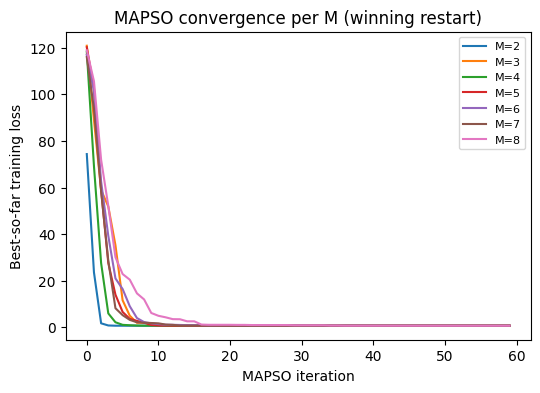

In [14]:
# --- 2.1b -- Diagnostic: did MAPSO plateau before N_EPOCHS_MAPSO? -------------------
# The FSC-inference-MAPSO library has NO built-in early stopping / patience for MAPSO
# (checked its source: the PSO loop in MAPSO.py always runs the full n_iterations, with
# no break-on-no-improvement condition -- by design, since its S3/S4 strategies rely on
# late-stage mutation and "jumping out" to escape local optima, which a naive patience
# check could cut off too early). tinyRNN's RNN training (Section 3) is different: it
# already has real early stopping via 'early_stop_counter' in the base_config.
#
# This curve is where N_EPOCHS_MAPSO in 2.1 comes from: find where the slowest M in your
# sweep flattens, add headroom, cap there. If you change M_CANDIDATES or swap in harder
# data, re-read this plot and retune N_EPOCHS_MAPSO (then FORCE_REFIT / delete the
# affected files in FSC_SWEEP_CACHE_DIR to refit at the new budget).
plt.figure(figsize=(6, 4))
for M in M_CANDIDATES:
    history = fitted_fscs[M].losses_epochs["train"]
    plt.plot(history, label=f"M={M}")
plt.xlabel("MAPSO iteration")
plt.ylabel("Best-so-far training loss")
plt.title("MAPSO convergence per M (winning restart)")
plt.legend(fontsize=8)
plt.show()

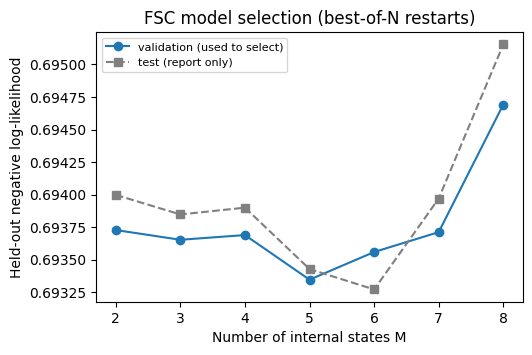

Validation loss is tied across M (all ~0.6933); parsimonious pick within 0.01 -> M* = 2
Per-M held-out TEST loss (report only, NOT used for selection):
   M=2: test = 0.6940
   M=3: test = 0.6938
   M=4: test = 0.6939
   M=5: test = 0.6934
   M=6: test = 0.6933
   M=7: test = 0.6940
   M=8: test = 0.6952


In [15]:
# --- 2.2 -- Model selection: validation is tied across M, so parsimony decides --------
Ms = sorted(fsc_val_losses)

plt.figure(figsize=(5.5, 3.5))
plt.plot(Ms, [fsc_val_losses[m] for m in Ms], "o-", label="validation (used to select)")
plt.plot(Ms, [fsc_test_losses[m] for m in Ms], "s--", c="gray", label="test (report only)")
plt.xlabel("Number of internal states M")
plt.ylabel("Held-out negative log-likelihood")
plt.title("FSC model selection (best-of-N restarts)")
plt.legend(fontsize=8)
plt.show()

# Two things to read off this plot:
#
# 1. WHY EVERY M TIES ON VALIDATION (~0.693). That floor is the cost of the very first trial of
#    each session, which no model can predict (there's no history yet): -log(1/2) = 0.693 nats.
#    Every M>=2 nails everything after that, so validation genuinely cannot separate them. When
#    models are tied on held-out data, parsimony decides: take the SMALLEST M within noise of the
#    best -> M=2, which is correct (WSLS is a 2-state strategy, and 4.2 shows even a larger fitted
#    FSC only ever occupies 2 states).
#
# 2. WHY THE TEST CURVE IS SPIKY (and why restarts did NOT flatten it). This is NOT model error,
#    and NOT a worse model being used on test -- it's the same best-of-N model, and it's
#    near-perfect. The spikes come from the DATA: the behavior follows win-stay-lose-shift almost
#    perfectly, but a tiny fraction of trials break the rule (a "lapse" -- e.g. staying after a
#    loss). In this 1000-session sample there is exactly ONE lapse in ~199k trials, and by luck it
#    landed in the TEST set (zero in validation). A near-deterministic model puts ~100% on the
#    rule-following action, so on that one lapse it eats a huge -log penalty (~73 nats), which
#    alone lifts the mean test loss. No model -- FSC, RNN, or a perfect oracle -- can predict a
#    trial where the subject broke their own rule, which is exactly why RESTARTS LEAVE IT
#    UNCHANGED: restarts fix fitting noise, but this is irreducible noise in the DATA, not the fit.
#    (On harder data where M matters, the same parsimony rule finds the real elbow; widen TOL or
#    use a per-session significance test, like the RNN's paired t-test in 3.3.)
val_min = min(fsc_val_losses.values())
TOL = 0.01
M_STAR = min(m for m in fsc_val_losses if fsc_val_losses[m] <= val_min + TOL)
print(f"Validation loss is tied across M (all ~{val_min:.4f}); parsimonious pick within {TOL} -> M* = {M_STAR}")
print("Per-M held-out TEST loss (report only, NOT used for selection):")
for m in Ms:
    print(f"   M={m}: test = {fsc_test_losses[m]:.4f}")

Loading cached best_fsc from fitted_models/random_init/fsc/best_fsc_M2.pkl


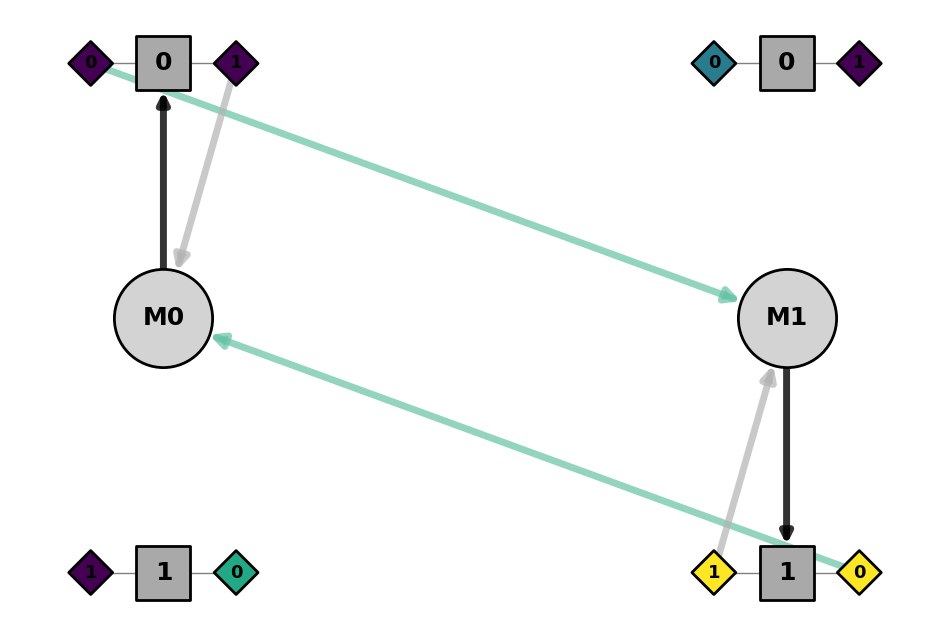

In [16]:
# --- 2.3 -- Refit M* on ALL data (best-of-N) and plot the FSC diagram ----------------
# The final interpretable model uses ALL sessions (no held-out at this stage -- we want the
# best possible fit for the diagram + the Section 4 analysis), so restarts here are ranked by
# their fit loss on all data. Cached like 2.1; FORCE_REFIT_BEST_FSC / deleting the file refits.
FORCE_REFIT_BEST_FSC = False
FSC_SAVE_DIR = f"fitted_models/{DATASET}/fsc/"
best_fsc_cache_path = os.path.join(FSC_SAVE_DIR, f"best_fsc_M{M_STAR}.pkl")

if not FORCE_REFIT_BEST_FSC and os.path.exists(best_fsc_cache_path):
    print(f"Loading cached best_fsc from {best_fsc_cache_path}")
    with open(best_fsc_cache_path, "rb") as f:
        best_fsc = pickle.load(f)
else:
    fsc_all_trajectories = sessions_to_fsc_trajectories(encoded_sessions)
    best_loss_all, best_fsc = None, None
    for r in range(N_RESTARTS):
        cand = fit_one_fsc(M_STAR, seed=FSC_SWEEP_SEED + 10000 + r, trajectories=fsc_all_trajectories)
        L = float(cand.compute_loss(fsc_all_trajectories))
        print(f"   restart {r}: all-data fit loss = {L:.4f}")
        if best_loss_all is None or L < best_loss_all:
            best_loss_all, best_fsc = L, cand
    print(f"   -> kept the restart with all-data fit loss {best_loss_all:.4f}")
    best_fsc.set_mode("generation")
    best_fsc.save(FSC_SAVE_DIR, filename=f"best_fsc_M{M_STAR}.pkl")

best_fsc.set_mode("generation")
obs_colors = plt.cm.Set2(np.linspace(0, 1, Y))
ax = best_fsc.plot_FSC(observation_node_colors=obs_colors, th_action_probs=1e-3, th_mem_transitions=1e-3)
plt.show()


## 3. tinyRNN training

Uses the repo's own `datasets.SimpleDataset` (their built-in generic-data entry
point) and the exact same training call
(`training_experiments.training.behavior_cv_training_config_combination`) used in the
paper's demo script `training_experiments/exp_monkeyV_minimal.py`: nested
cross-validation (outer folds = test sets, inner folds = train/val split) with
multiple random seeds per fold, sweeping `hidden_dim`. Model selection (picking the
smallest hidden size not significantly worse than larger ones) uses the paper's own
`analyzing_experiments.analyzing_perf.select_final_rnn_perf`.

**This will be slow-ish on CPU for real data / larger sweeps.** `outer_splits=5,
inner_splits=4, seed_num=2` (the paper's own minimal-demo defaults) means `5*4*2 =
40` models trained *per hidden_dim value*. Reduce these for a quick check, restore
them for a paper-faithful run.


In [17]:

_use_tinyrnn_path()
os.chdir("tinyRNN")   # training.py assumes it's run from the repo root (path_settings, data_path.json)

from datasets import Dataset
from agents import Agent
from training_experiments.training import behavior_cv_training_config_combination
from analyzing_experiments.analyzing_perf import select_final_rnn_perf


In [18]:
# --- 3.1 -- Build SimpleDataset files (RNN trains on fit+val, HOLDS OUT test) --------
# The RNN must hold out the SAME test set as the FSC, so Section 3.5 can compare them on
# identical trials. So it trains on fit+val only; test_sessions is untouched until 3.5.
input_format = [
    dict(name="action", one_hot_classes=A),
    dict(name="observation", one_hot_classes=Y),
]
if HAS_REWARD:
    input_format.append(dict(name="reward"))
INPUT_DIM = sum(fmt.get("one_hot_classes", 1) for fmt in input_format)

os.makedirs("files/SimpleDatasetInput", exist_ok=True)
def make_rnn_spec(session_list, filename):
    """Write a SimpleDataset input file for `session_list`, return its behav_data_spec.
    Reused for the training set (3.1), all sessions (3.4), and the test set (3.4)."""
    data = {"action": [s["actions"] for s in session_list],
            "observation": [s["observations"] for s in session_list]}
    if HAS_REWARD:
        data["reward"] = [s["reward"] for s in session_list]
    fpath = f"files/SimpleDatasetInput/{filename}"
    joblib.dump(data, fpath)
    return {"dataset": "Simple", "data": fpath, "input_format": input_format,
            "output_dim": A, "target_name": "action"}

behav_data_spec = make_rnn_spec(train_sessions + val_sessions, "behavior_train.pkl")
print(f"RNN trains on {len(train_sessions) + len(val_sessions)} sessions (fit+val); "
      f"{len(test_sessions)} test sessions held out.")
print(f"input_dim = {INPUT_DIM}   output_dim (A) = {A}")

RNN trains on 800 sessions (fit+val); 200 test sessions held out.
input_dim = 4   output_dim (A) = 2


In [19]:

# --- 3.2 -- Official nested-CV training sweep over hidden_dim -----------------------
# Caching is already handled by tinyRNN itself: `_train_one_agent` (training_experiments/
# training.py) checks for a 'temp_summary.pkl' in each model's folder under
# MODEL_SAVE_PATH (tinyRNN/files/saved_model/, set in Patch 1) and skips straight to
# loading it if present. So re-running this cell only trains configs that aren't
# finished yet -- it won't redo completed (hidden_dim, outer_fold, inner_fold, seed)
# combinations.
#
# FORCE_RETRAIN_RNN below is the same kind of override toggle as FORCE_REFIT_FSC_SWEEP /
# FORCE_REFIT_BEST_FSC in Section 2: pure notebook-level file deletion using tinyRNN's
# own `path_settings.MODEL_SAVE_PATH`, run *before* calling the library's (unmodified)
# `behavior_cv_training_config_combination`. It does not touch any vendored tinyRNN
# code -- same as the FSC caching, it's just I/O wrapped around the library call.
FORCE_RETRAIN_RNN = False # <-- set to True to wipe this experiment's cache and retrain everything
EXP_FOLDER = f"exp_{DATASET}"

if FORCE_RETRAIN_RNN:
    import shutil
    from path_settings import MODEL_SAVE_PATH
    exp_dir = MODEL_SAVE_PATH / EXP_FOLDER
    if exp_dir.exists():
        shutil.rmtree(exp_dir)
        print(f"Deleted {exp_dir} -- every hidden_dim/fold/seed combo below will retrain from scratch.")
    else:
        print(f"{exp_dir} doesn't exist yet -- nothing to delete, will train fresh anyway.")

# Early stopping: 'early_stop_counter' below IS real patience-based early stopping
# (RNNAgentTrainer.py stops once validation loss hasn't improved for that many epochs),
# using the paper's own default of 200. Unlike MAPSO on the FSC side, this is already
# as fast as the paper's authors made it -- lower it only if you want to trade fidelity
# for speed.
HIDDEN_DIM_CANDIDATES = [1, 2, 3, 4, 5, 6, 7, 8]   # RNN sizes to try (the paper sweeps a range)
# We start at hidden_dim=1 here, but the FSC sweep in 2.1 starts at M=2 -- deliberate, not an
# inconsistency. An FSC with 1 memory state has NO memory: a single state can't be
# history-dependent, so it's a dead baseline we skip. A GRU with 1 hidden unit is different --
# that unit is a CONTINUOUS number updated each trial, so it can still carry information (slide
# toward "play A" vs "play B"). One continuous unit is a real model; one discrete state is not.
# So the two x-axes just start at different points; the FSC-vs-RNN overlay in 3.5 begins at M=2 / H=1.

base_config = {
    ### dataset info
    "dataset": "Simple",
    "behav_format": "tensor",
    "behav_data_spec": behav_data_spec,
    ### model info
    "agent_type": "RNN",
    "rnn_type": "GRU",
    "input_dim": INPUT_DIM,
    "hidden_dim": 2,           # overwritten by config_ranges below
    "output_dim": A,
    "device": "cpu",           # set to "cuda" if you have a GPU
    "output_h0": True,
    "trainable_h0": False,
    "readout_FC": True,
    "one_hot": False,
    ### training info for one model
    "lr": 0.005,
    "l1_weight": 1e-5,
    "weight_decay": 0,
    "penalized_weight": "rec",
    "max_epoch_num": 2000,        # paper default; lower this for a quick smoke test
    "early_stop_counter": 200,
    ### training info for many models on dataset (paper's own nested-CV settings)
    "outer_splits": 5,
    "inner_splits": 4,
    "seed_num": 2,
    ### additional training info
    "save_model_pass": "minimal",
    "training_diagnose": None,
    "exp_folder": EXP_FOLDER,
}
config_ranges = {
    "rnn_type": ["GRU"],
    "hidden_dim": HIDDEN_DIM_CANDIDATES,
    "readout_FC": [True],
    "l1_weight": [1e-5],
}

behavior_cv_training_config_combination(base_config, config_ranges, n_jobs=8, verbose_level=1)

Already existing  files/saved_model/exp_random_init/rnn_type-GRU.hidden_dim-1.readout_FC-True.l1_weight-1e-05/allfold_summary.pkl
Already existing  files/saved_model/exp_random_init/rnn_type-GRU.hidden_dim-2.readout_FC-True.l1_weight-1e-05/allfold_summary.pkl
Already existing  files/saved_model/exp_random_init/rnn_type-GRU.hidden_dim-3.readout_FC-True.l1_weight-1e-05/allfold_summary.pkl
Already existing  files/saved_model/exp_random_init/rnn_type-GRU.hidden_dim-4.readout_FC-True.l1_weight-1e-05/allfold_summary.pkl
Already existing  files/saved_model/exp_random_init/rnn_type-GRU.hidden_dim-5.readout_FC-True.l1_weight-1e-05/allfold_summary.pkl
Already existing  files/saved_model/exp_random_init/rnn_type-GRU.hidden_dim-6.readout_FC-True.l1_weight-1e-05/allfold_summary.pkl
Already existing  files/saved_model/exp_random_init/rnn_type-GRU.hidden_dim-7.readout_FC-True.l1_weight-1e-05/allfold_summary.pkl
Already existing  files/saved_model/exp_random_init/rnn_type-GRU.hidden_dim-8.readout_FC-T

Searching for summary files...
Found 8 summary files.
Filtering by {'agent_type': 'RNN'}


100%|██████████| 8/8 [00:00<00:00, 612.42it/s]


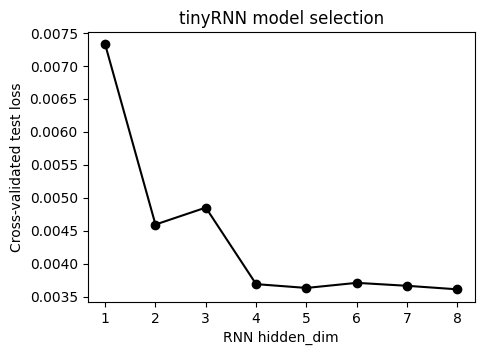

Selected hidden_dim: H* = 5
   hidden_dim  less_than_former  test_loss
0           1                 1   0.007325
1           2                 1   0.004592
2           3                 0   0.004849
3           4                 1   0.003688
4           5                 1   0.003630
5           6                 0   0.003707
6           7                 0   0.003663
7           8                 0   0.003609


In [20]:

# --- 3.3 -- Official model selection: pick the smallest sufficient hidden_dim -------
perf, summary, dim_est = select_final_rnn_perf(EXP_FOLDER, return_dim_est=True, verbose=False)

plt.figure(figsize=(5, 3.5))
plt.plot(dim_est["hidden_dim"], dim_est["test_loss"], "o-", c="k")
plt.xlabel("RNN hidden_dim")
plt.ylabel("Cross-validated test loss")
plt.title("tinyRNN model selection")
plt.show()

# `less_than_former` (from the paper's own select_final_rnn_perf) is 1 at hidden_dim h iff
# h's cross-validated loss is significantly lower (paired t-test over outer folds, p<0.05)
# than EVERY smaller candidate's; it's 0 as soon as some smaller dim is statistically tied.
# H* = the LARGEST hidden_dim with the flag still 1 -- this exactly reproduces the repo's
# own get_dim_from_perf (analyzing_perf.py). Caveat: on near-deterministic data all dims
# are near-perfect, so the t-test can flag a behaviorally-trivial improvement as
# significant (here H*=4 for WSLS, which is really a 1-2 dim strategy). Read H* as an
# upper bound and sanity-check it against the near-flat loss curve.
improved = dim_est.loc[dim_est["less_than_former"] == 1, "hidden_dim"]
H_STAR = int(improved.max()) if len(improved) else int(dim_est["hidden_dim"].min())
print(f"Selected hidden_dim: H* = {H_STAR}")
print(dim_est[["hidden_dim", "less_than_former", "test_loss"]])


In [21]:

# --- 3.4 -- Load the best H*-sized model and extract hidden-state trajectories ------
# Picks, among all (outer_fold, inner_fold, seed) runs at hidden_dim=H_STAR, the one
# with the lowest combined train+val loss (mirrors 'compete_from_keys' logic used
# internally by select_final_rnn_perf for picking a single instance per fold).
h_star_rows = summary[summary["hidden_dim"] == H_STAR].copy() if "hidden_dim" in summary.columns \
    else summary[summary["config"].apply(lambda c: c["hidden_dim"] == H_STAR)].copy()
h_star_rows = h_star_rows.sort_values("trainval_loss")
best_row = h_star_rows.iloc[0]
best_model_path = best_row["model_path"]
print("Loading best model from:", best_model_path)

rnn_config = dict(base_config)
rnn_config.update({"hidden_dim": H_STAR, "seed": 0})
best_agent = Agent("RNN", config=rnn_config)
best_agent.load(str(best_model_path))

# (a) Hidden-state trajectories on ALL sessions (for the Section 4/5 representation analysis).
#     One deterministic forward pass -- given fixed weights the hidden state is fully determined.
spec_all = make_rnn_spec(encoded_sessions, "behavior_all.pkl")
dt_all = Dataset("Simple", behav_data_spec=spec_all).behav_to(rnn_config)
data_all = dt_all.get_behav_data(range(dt_all.batch_size), rnn_config)
rnn_hidden_states = best_agent.forward(data_all, standard_output=True)["internal"]

# (b) Per-trial P(actual action) on the held-out TEST sessions (for the Section 3.5 comparison).
#     pointwise_loss gives per-trial -log P(actual action); exp(-that) = the probability.
spec_test = make_rnn_spec(test_sessions, "behavior_test.pkl")
dt_test = Dataset("Simple", behav_data_spec=spec_test).behav_to(rnn_config)
data_test = dt_test.get_behav_data(range(dt_test.batch_size), rnn_config)
rnn_test_out = best_agent.forward(data_test, standard_output=True, pointwise_loss=True)
rnn_test_probs = [np.exp(-np.asarray(b)) for b in rnn_test_out["behav_loss"]]

print(f"Hidden states for {len(rnn_hidden_states)} sessions "
      f"(e.g. session 0 shape = {rnn_hidden_states[0].shape}); "
      f"per-trial test probs for {len(rnn_test_probs)} sessions.")
os.chdir("..")   # back to the notebook's working directory


Loading best model from: exp_random_init/rnn_type-GRU.hidden_dim-5.readout_FC-True.l1_weight-1e-05/outerfold3_innerfold3_seed0
Total batch size: 1000
Total batch size: 200
Hidden states for 1000 sessions (e.g. session 0 shape = (201, 5)); per-trial test probs for 200 sessions.


Comparing on 200 held-out test sessions (40,000 trials).

METHOD 1 -- predictive per-trial log-likelihood (higher = better; nats):
   FSC:  mean log-lik = -0.00347   (NLL 0.00347)
   RNN:  mean log-lik = -0.00360   (NLL 0.00360)
   paired: FSC assigns higher P to the truth on 99.73% of trials, RNN on 0.27%
   [synthetic-from-FSC sanity check, FSC should be >= RNN]: PASS

METHOD 2 -- do the two models assign the same probability per trial?
   correlation of per-trial P(actual action): r = 0.9987
   mean |P_FSC - P_RNN| per trial = 0.00027


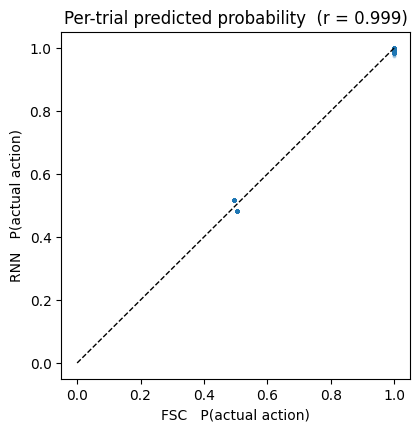

In [22]:
# --- 3.5 -- Compare the two models fairly: predicted probability, same held-out trials ----
# The OLD comparison plotted two averaged LOSSES computed on different data by different
# equations -- not valid. The fair comparison uses each model's PREDICTED PROBABILITY of the
# action that actually happened, per trial, on the SAME held-out test sessions (both models
# held these out while fitting). From those per-trial probabilities we run two methods:
#   Method 1 -- predictive log-likelihood, paired per trial: which model predicts behavior better.
#   Method 2 -- per-trial probability agreement: do the two models "think" alike, trial by trial.
_use_fsc_path()   # restore FSC modules (Section 3 left tinyRNN on sys.path)

def fsc_per_trial_prob(fsc, session_list):
    """Per-trial P(actual action | history) under the FSC, from its own belief recursion.
    General -- works for any number of actions / memory states."""
    fsc.set_mode("generation")
    T_mat = fsc.get_TMat(); rho = np.asarray(fsc.get_rho()); pol = np.asarray(fsc.get_action_policy())
    out = []
    for s in session_list:
        a, o = s["actions"], s["observations"]
        b = rho.copy(); p = np.zeros(len(a))
        for t in range(len(a)):
            p[t] = (b @ pol)[int(a[t])]                       # P(chosen action | current belief)
            step = T_mat[int(o[t]), :, :, int(a[t])]          # advance the belief with what happened
            bn = b @ step; tot = bn.sum()
            b = bn / tot if tot > 0 else np.ones(fsc.M) / fsc.M
        out.append(p)
    return out

# FSC used here = the sweep model at M* (fit on the FIT set -> holds out test), NOT the all-data
# best_fsc from 2.3. rnn_test_probs came from 3.4 and were also held out from test.
fsc_test_probs = fsc_per_trial_prob(fitted_fscs[M_STAR], test_sessions)

fp = np.concatenate(fsc_test_probs)
rp = np.concatenate([rnn_test_probs[i][:len(fsc_test_probs[i])] for i in range(len(fsc_test_probs))])
fll = np.log(np.clip(fp, 1e-300, 1.0)); rll = np.log(np.clip(rp, 1e-300, 1.0))

print(f"Comparing on {len(test_sessions)} held-out test sessions ({len(fp):,} trials).\n")
print("METHOD 1 -- predictive per-trial log-likelihood (higher = better; nats):")
print(f"   FSC:  mean log-lik = {fll.mean():.5f}   (NLL {-fll.mean():.5f})")
print(f"   RNN:  mean log-lik = {rll.mean():.5f}   (NLL {-rll.mean():.5f})")
print(f"   paired: FSC assigns higher P to the truth on {100*np.mean(fll > rll):.2f}% of trials, "
      f"RNN on {100*np.mean(rll > fll):.2f}%")
# For data generated by an FSC, the FSC is the ground truth -> it should not be beaten. This
# line is a dataset-specific sanity check, not part of the general method.
print(f"   [synthetic-from-FSC sanity check, FSC should be >= RNN]: "
      f"{'PASS' if fll.mean() >= rll.mean() - 1e-9 else 'FAIL -- RNN beats ground truth, investigate'}\n")

print("METHOD 2 -- do the two models assign the same probability per trial?")
r = np.corrcoef(fp, rp)[0, 1]
print(f"   correlation of per-trial P(actual action): r = {r:.4f}")
print(f"   mean |P_FSC - P_RNN| per trial = {np.mean(np.abs(fp - rp)):.5f}")

plt.figure(figsize=(4.5, 4.5))
plt.scatter(fp, rp, s=4, alpha=0.2)
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("FSC   P(actual action)"); plt.ylabel("RNN   P(actual action)")
plt.title(f"Per-trial predicted probability  (r = {r:.3f})")
plt.show()

## 4. Looking for connections between the FSC and the RNN

Everything below this point is our own analysis, **not** part of either paper's official
pipeline — a starting point, not the final word. Feel free to gut it.

### 4.1 Reading out the FSC's internal state, trial by trial
We want to watch which internal state the FSC is in as it moves through the real behavior, so
we can line it up against the RNN's hidden state at the same trials. The catch: the FSC is a
probabilistic model and doesn't hand you that state history when you fit it — you get the
fitted machine, not a play-by-play.

So we reconstruct it. We replay each real `(action, observation)` sequence through the fitted
FSC and, at every trial, track the probability that it's in each memory state — call this its
"belief". Each trial's belief is updated from the previous one using the FSC's own transition
rules and then renormalized:

$$b_t(m') \propto \sum_m b_{t-1}(m)\, T(a_{t-1}, m' \mid m, y_{t-1})$$

This is a standard "forward-filtering" pass — the very same computation the FSC already runs
inside its own loss function, except we keep the per-trial beliefs instead of throwing them
away. It uses only the model's own public outputs (`get_TMat()` / `get_rho()`), so it's the
FSC's own math applied to the data, not a new model.

In [23]:

def decode_fsc_belief_states(fsc, actions, observations):
    '''Forward-filtering belief b_t(m) = P(memory state = m | actions[:t], observations[:t]),
    for t = 0..T (b_0 = rho, the prior; b_T = belief after the last trial).
    `fsc` must be in 'generation' mode (so get_TMat()/get_rho() return numpy arrays).
    Returns array of shape (T+1, M).'''
    T_mat = fsc.get_TMat()   # shape (Y, M, M, A): axes (obs, prev_mem, next_mem, action)
    rho = np.asarray(fsc.get_rho())
    M = fsc.M

    beliefs = np.zeros((len(actions) + 1, M))
    beliefs[0] = rho
    b = rho.copy()
    for t in range(len(actions)):
        a_t, y_t = int(actions[t]), int(observations[t])
        step = T_mat[y_t, :, :, a_t]     # (prev_mem, next_mem)
        b_new = b @ step                 # sum_m b[m] * step[m, m']
        total = b_new.sum()
        b = b_new / total if total > 0 else np.ones(M) / M   # degenerate fallback
        beliefs[t + 1] = b
    return beliefs

# Restore the FSC import path: after Section 3 put tinyRNN on sys.path, and the FSC's
# generation code lazily JIT-compiles a numba helper from ITS OWN utils.py -- if
# tinyRNN's identically-named utils shadows it at compile time, that import fails.
_use_fsc_path()
best_fsc.set_mode("generation")
fsc_belief_states = [
    decode_fsc_belief_states(best_fsc, s["actions"], s["observations"])
    for s in encoded_sessions
]
print(f"Decoded FSC belief-state trajectories for {len(fsc_belief_states)} sessions, "
      f"e.g. session 0 shape = {fsc_belief_states[0].shape}")

# sanity check: same (T+1) length convention as the RNN's hidden states (output_h0=True)
mismatches = [i for i in range(len(encoded_sessions))
              if fsc_belief_states[i].shape[0] != rnn_hidden_states[i].shape[0]]
print("Sessions with mismatched lengths (should be empty):", mismatches)


Decoded FSC belief-state trajectories for 1000 sessions, e.g. session 0 shape = (201, 2)
Sessions with mismatched lengths (should be empty): []


In [24]:
# --- Trial-by-trial alignment: raw data, side by side, for one example session ------
# This TABLE is just an illustrative peek -- one session, so you can eyeball the FSC's belief and
# the RNN's hidden numbers changing together trial by trial. The table itself isn't used
# downstream, but the arrays behind it (fsc_belief_states, rnn_hidden_states) ARE the raw material
# for the occupancy check (4.2), the PCA (4.3), and the linear probe (Section 5).
example_idx = 0
acts = encoded_sessions[example_idx]["actions"]
obs = encoded_sessions[example_idx]["observations"]

alignment_table = pd.DataFrame({
    "trial": np.arange(len(rnn_hidden_states[example_idx])),
    "action": np.concatenate([[np.nan], acts]),
    "observation": np.concatenate([[np.nan], obs]),
    **{f"fsc_belief_m{m}": fsc_belief_states[example_idx][:, m] for m in range(M_STAR)},
    **{f"rnn_hidden_h{h}": rnn_hidden_states[example_idx][:, h] for h in range(H_STAR)},
})
alignment_table

,trial,action,observation,fsc_belief_m0,fsc_belief_m1,rnn_hidden_h0,rnn_hidden_h1,rnn_hidden_h2,rnn_hidden_h3,rnn_hidden_h4
0,0,NaN,NaN,4.880689e-01,5.119311e-01,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,1.0,0.0,1.000000e+00,1.910276e-09,-0.759472,0.368663,-0.537193,-0.624817,-0.163187
2,2,0.0,1.0,1.000000e+00,4.323099e-14,-0.849992,-0.843191,0.208199,-0.753168,0.905876
3,3,0.0,1.0,1.000000e+00,4.323041e-14,-0.846238,-0.822873,0.296361,-0.884238,0.934278
4,4,0.0,1.0,1.000000e+00,4.323041e-14,-0.849055,-0.819732,0.361022,-0.911905,0.937501
...,...,...,...,...,...,...,...,...,...,...
196,196,1.0,0.0,1.000000e+00,1.899204e-09,-0.663692,0.628593,-0.982730,-0.808030,0.273667
197,197,0.0,0.0,9.627837e-10,1.000000e+00,0.926356,0.693317,0.398960,0.863041,0.321852
198,198,1.0,0.0,1.000000e+00,1.899204e-09,-0.698636,0.721552,-0.983151,-0.817094,0.300353
199,199,0.0,1.0,1.000000e+00,4.323099e-14,-0.804144,-0.863555,-0.161152,-0.855510,0.947424


### 4.2 How much of the FSC's memory does it actually use?
`M*` states were fit, but a model can be fit with M states and still behave, in practice,
like it only needs a handful. We check directly: take the most-likely state (argmax of
the belief) at each trial across every session, and see how much of the probability mass
each state actually carries -- then check what those heavily-used states correspond to in
the real (previous action, previous outcome) history.

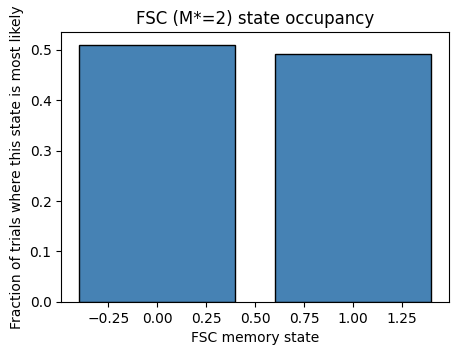

States with >1% occupancy: 2 out of 2

Dominant FSC state vs. (previous action, previous outcome) -- rows = FSC state:
       acted 0, lost  acted 0, won  acted 1, lost  acted 1, won
row_0                                                          
0                  0         59985          41887             0
1              41860             0              0         55268


In [25]:
# --- 4.2 -- FSC memory occupancy, and what each occupied state corresponds to ---------
# "Decide-time" convention (matches the loss / RNN section below): belief_states[i][t] is
# the belief used to choose action[t], built from history strictly before t. We drop the
# LAST belief per session (the posterior after the final trial) since it was never used to
# make a prediction -- exactly like the RNN's own loss drops its last score.
combo_labels_list = []
for s in encoded_sessions:
    a, o = s["actions"], s["observations"]
    T = len(a)
    labels = [-1] + [a[t] * Y + o[t] for t in range(T - 1)]   # -1 = trial 0, no previous trial
    combo_labels_list.append(np.array(labels))
combo_labels = np.concatenate(combo_labels_list)
combo_names = {0: "acted 0, lost", 1: "acted 0, won", 2: "acted 1, lost", 3: "acted 1, won"}

decide_time_fsc = np.concatenate([b[:-1] for b in fsc_belief_states], axis=0)
hard_states = decide_time_fsc.argmax(axis=1)
occupancy = np.bincount(hard_states, minlength=M_STAR) / len(hard_states)

# Bar chart: one bar per memory state. The x-axis positions are just WHERE each bar sits
# (state 0 centered at x=0, state 1 at x=1) -- not data. The information is the bar HEIGHTS:
# the fraction of trials where that state is the most likely one.
plt.figure(figsize=(5, 3.5))
plt.bar(range(M_STAR), occupancy, color="steelblue", edgecolor="k")
plt.xlabel("FSC memory state"); plt.ylabel("Fraction of trials where this state is most likely")
plt.title(f"FSC (M*={M_STAR}) state occupancy")
plt.show()

used = (occupancy > 0.01).sum()
print(f"States with >1% occupancy: {used} out of {M_STAR}\n")

mask = combo_labels != -1
ct = pd.crosstab(hard_states[mask], combo_labels[mask])
ct.columns = [combo_names[c] for c in ct.columns]
print("Dominant FSC state vs. (previous action, previous outcome) -- rows = FSC state:")
print(ct)

### 4.3 The RNN's hidden-state geometry, and what it encodes

The RNN's internal state is a continuous **H**-dimensional vector per trial -- a list of H numbers,
with no built-in labels, unlike the FSC's discrete states. Every point we're about to plot is one
trial's hidden vector, taken from the single forward pass in 3.4 (one point per trial of every
session -- no new run). *For this dataset: H = 5, and N ≈ 199,000 points.*

**The problem:** we can't look at an H-dimensional cloud of points directly. So we flatten it to
2D with **PCA (Principal Component Analysis)**, purely to *see its shape*.

**What PCA actually does** (this is the "what are the two variables?" question). It does **not**
pick two of the hidden units. It invents two brand-new axes out of the data:

- **PC1** = the single direction through the cloud along which the points are *most spread out*.
- **PC2** = the direction of the *next*-most spread, at a right angle to PC1.

Each new axis is a fixed weighted mix of the original H hidden units
(e.g. `PC1 = 0.41·h₁ − 0.68·h₂ + …`); the weights are computed as the top two eigenvectors of the
data's covariance matrix. So the two plot axes are simply the two directions that preserve as much
of the cloud's spread as possible when we squash H-D down to 2-D. They carry no built-in meaning --
we read meaning into them *afterward*, by coloring.

We color each point by the (previous action, previous outcome) of the immediately preceding trial
(the `combo_labels` from 4.2) -- for WSLS that is the only thing the rule depends on. If the colors
fall into clean, separated regions, the black-box RNN has organized its state space around the same
few history-contexts the FSC represents explicitly.

**Important:** the k-means "purity" printed below clusters the **raw H-D hidden state, not the 2-D
PCA picture**, and it does *not* use the color labels to form the clusters (the labels only score
them afterward). So it's an objective check -- not an artifact of the projection or of the coloring.


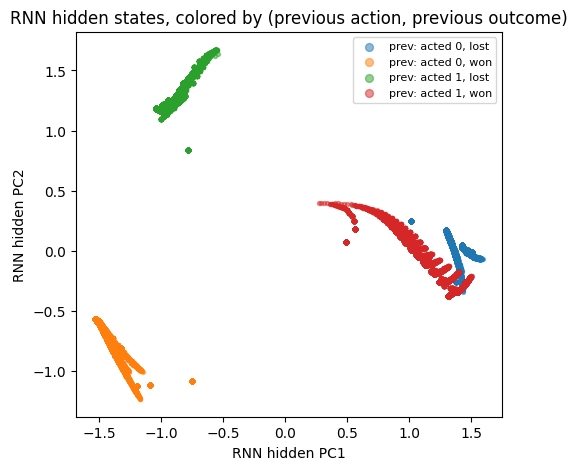

k-means (k=4) on the raw 5-d hidden state vs. (prev action, prev outcome): 100.0% purity
       acted 0, lost  acted 0, won  acted 1, lost  acted 1, won
row_0                                                          
0                  0             0          41887             0
1              41845             0              0             0
2                  0         59985              0             0
3                 15             0              0         55268


In [26]:
from sklearn.decomposition import PCA
# --- 4.3 -- The RNN's hidden states, colored by (previous action, previous outcome) ---
# Same decide-time convention as 4.2: drop the last hidden state per session (index T),
# since RNNAgent.py's own loss drops it too (it was never used to predict anything).
decide_time_rnn = np.concatenate([h[:-1] for h in rnn_hidden_states], axis=0)

# NumPy on Apple Silicon (Accelerate BLAS backend) is known to throw spurious
# divide-by-zero/overflow RuntimeWarnings on matmul for some array shapes, even when
# every value involved is finite and correct (verified: no NaN/Inf in decide_time_rnn,
# and the clustering result below is exactly right) -- so we suppress just this class
# of warning rather than leave unexplained red text next to a correct result.
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    if decide_time_rnn.shape[1] > 2:
        coords_labeled = PCA(n_components=2).fit_transform(decide_time_rnn)
    else:
        coords_labeled = np.pad(decide_time_rnn, ((0, 0), (0, 2 - decide_time_rnn.shape[1])))

if decide_time_rnn.shape[1] > 2:
    xlabel2, ylabel2 = "RNN hidden PC1", "RNN hidden PC2"
else:
    xlabel2, ylabel2 = "RNN hidden dim 1", "RNN hidden dim 2"

mask = combo_labels != -1
plt.figure(figsize=(5.5, 5))
for combo_val, name in combo_names.items():
    sel = mask & (combo_labels == combo_val)
    plt.scatter(coords_labeled[sel, 0], coords_labeled[sel, 1], s=8, alpha=0.5, label=f"prev: {name}")
plt.xlabel(xlabel2); plt.ylabel(ylabel2)
plt.legend(fontsize=8, markerscale=2)
plt.title("RNN hidden states, colored by (previous action, previous outcome)")
plt.show()

# Quantify the visual impression: cluster the RAW hidden state (not the 2D projection) and
# check how purely each cluster maps onto one (previous action, previous outcome) combo.
from sklearn.cluster import KMeans
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    km = KMeans(n_clusters=4, n_init=10, random_state=0).fit(decide_time_rnn[mask])
ct_rnn = pd.crosstab(km.labels_, combo_labels[mask])
ct_rnn.columns = [combo_names[c] for c in ct_rnn.columns]
purity = ct_rnn.max(axis=1).sum() / ct_rnn.values.sum()
print(f"k-means (k=4) on the raw {H_STAR}-d hidden state vs. (prev action, prev outcome): "
      f"{purity*100:.1f}% purity")
print(ct_rnn)

### 4.4 Does the fitted FSC actually reproduce win-stay/lose-shift behavior?
Everything above inspects the FSC's *internal* state. The authors' own demos (e.g.
MouseBandits) validate a fitted FSC a different way: **generate** synthetic behavior from
it and compare to the real thing. We do the same, without needing a custom environment
model -- feed the FSC the REAL observation sequences from held-out sessions via
`generate_single_trajectory(observations=...)`, let it generate its OWN actions in
response, and compare the resulting stay/shift rates to the real data's.

In [27]:
# --- 4.4 -- Generate behavior from the fitted FSC and compare to the real data ----------
# Restore the FSC import path: after Section 3 put tinyRNN on sys.path, and the FSC's
# generation code lazily JIT-compiles a numba helper from ITS OWN utils.py -- if
# tinyRNN's identically-named utils shadows it at compile time, that import fails.
_use_fsc_path()
best_fsc.set_mode("generation")

def stay_rates(actions, observations):
    actions = np.asarray(actions); observations = np.asarray(observations)
    stay = (actions[1:] == actions[:-1]).astype(float)
    prev_obs = observations[:-1]
    p_win = stay[prev_obs == 1].mean() if (prev_obs == 1).any() else np.nan
    p_lose = stay[prev_obs == 0].mean() if (prev_obs == 0).any() else np.nan
    return p_win, p_lose

real_rates, gen_rates = [], []
for s in test_sessions:
    o = s["observations"]
    real_rates.append(stay_rates(s["actions"], o))
    generated = best_fsc.generate_single_trajectory(observations=o)
    gen_rates.append(stay_rates(generated["actions"], o))
real_rates = np.array(real_rates); gen_rates = np.array(gen_rates)

print("                        real data   FSC-generated")
print(f"P(stay | previous WIN):   {np.nanmean(real_rates[:,0]):.4f}       {np.nanmean(gen_rates[:,0]):.4f}")
print(f"P(stay | previous LOSE):  {np.nanmean(real_rates[:,1]):.4f}       {np.nanmean(gen_rates[:,1]):.4f}")
print("\nThe fitted FSC, when driven by the real held-out observation sequences, reproduces\n"
      "the win-stay/lose-shift pattern almost exactly -- direct evidence the fitted internal\n"
      "dynamics correspond to the actual behavioral rule, not just a loss number.")

                        real data   FSC-generated
P(stay | previous WIN):   1.0000       1.0000
P(stay | previous LOSE):  0.0000       0.0000

The fitted FSC, when driven by the real held-out observation sequences, reproduces
the win-stay/lose-shift pattern almost exactly -- direct evidence the fitted internal
dynamics correspond to the actual behavioral rule, not just a loss number.


## 5. Do the two models actually share an internal representation?

By now we have, for **every trial**, two separate readouts of "what the model is thinking":
the FSC's belief and the RNN's hidden state. Sections 4.2-4.3 showed both line up with the
recent (action, outcome) history -- but that was by eye. Now we test it directly with a
**linear probe**: train a simple classifier to predict *one* model's state from the *other*
model's state, and see how accurate it gets. If a plain straight-line classifier can do it, the
information is genuinely *inside* that representation, not just visually suggestive.

**The exact variables the probe uses** (each has one row per trial, all aligned to the same
trials). `mask` drops the first slot of each session -- the state *before trial 1* -- for two
reasons: it has no preceding (action, outcome) to label it with, and it's the same generic
"haven't started yet" state for every session, so it carries no information. That drops each
session by one trial, leaving **N** usable trials in total.

| variable | what it is | shape |
|---|---|---|
| `decide_time_rnn` | the RNN's hidden numbers at each trial -- one per hidden unit (from 4.3) | (N, H) |
| `decide_time_fsc` | the FSC's belief -- one probability per FSC state, i.e. how likely each state is (from 4.2) | (N, M) |
| `hard_states` | which FSC state is the winner that trial (0 … M-1) | (N,) |
| `km.labels_` | which of the RNN's clusters that trial fell into (0 … K-1, from 4.3) | (N,) |

> **For the dataset loaded here:** M = 2 FSC states, H = 5 RNN hidden units, K = 4 RNN clusters,
> and N = 1000 sessions × 199 trials = **199,000** trials. (These four numbers are what change
> when you swap the dataset; everything below is written in terms of M, H, K, N so it stays correct.)

We run the probe in **both directions** -- in each, one array is the *input features* and the
other model's label is the *target to predict*:

- **A) RNN → FSC:** features = `decide_time_rnn` (the RNN's hidden numbers), target = `hard_states`
  (the FSC's state). A high score means the RNN already encodes whatever the FSC's state captures.
- **B) FSC → RNN:** features = `decide_time_fsc` (the FSC's belief), target = `km.labels_`
  (the RNN's cluster). If this is much weaker than A, the RNN is holding information the FSC discards.

**How the accuracy is scored -- and note this is _not_ the Section 2 fit/validation/test split.**
That split existed only to choose the FSC's number of states. The probe is a different question,
so it scores itself with its own **5-fold cross-validation**: chop the trials into 5 equal parts,
train the classifier on 4 parts, score it on the 5th part it never saw, rotate so each part is the
held-out one exactly once, and average the 5 scores. Cross-validation just guarantees the
classifier is always graded on trials it didn't train on, so the number isn't inflated by
memorization.


### How the linear probe works

For each trial you have an input vector **X** (one model's internal state) and a target label **y**
(the *other* model's state). A logistic-regression classifier turns X into a guess in two steps:

1. **Weighted sum -- the "linear" part.** With learned weights **w** (one per input number) and a
   learned bias **b**:  `z = w·X + b = w₁X₁ + w₂X₂ + … + b`.
2. **Squash to a probability.** When the target has **2 classes** (e.g. predicting the FSC's state
   when M=2), the logistic (sigmoid) function: `P(class = 1) = σ(z) = 1 / (1 + e^(−z))`, and predict
   class 1 if that is above 0.5. When it has **more than 2** classes (e.g. the K RNN clusters) it's
   the *softmax* version: one score `z_k = w_k·X + b_k` per class, then
   `P(class k) = e^(z_k) / Σ_j e^(z_j)`, predict the highest.

**What is actually trainable: only `w` and `b`.** X and y are fixed data -- X is the internal-state
vector you feed *in*, y is the answer you're trying to hit. The weights set the *orientation* of the
decision boundary; the bias sets *where it sits* (like the `+b` intercept in `y = mx + b` -- without
it the boundary is forced through the all-zeros input point). There is one weight per input feature
(**H** for the RNN's hidden vector, **M** for the FSC's belief) and one bias per output.

**Training = choosing `w`, `b`** to make the predicted probabilities match the true labels, by
minimizing the cross-entropy loss `L = −Σ ln P(correct label)` with gradient descent. (In the code,
`StandardScaler` first rescales each feature to mean 0 / spread 1 so the optimizer converges nicely;
it doesn't change what's being asked.)

**Why deliberately use the weakest classifier.** A linear probe can only draw straight boundaries.
If even a straight boundary reads one representation out of the other perfectly, the information
isn't just present -- it's present *cleanly* (linearly separable). A near-100% score with a linear
probe is the strongest possible version of "these two internal states encode the same thing."


In [28]:
# --- 5.1 -- Linear probes between the two models' internal states --------------------
# A "probe" = train a simple linear classifier to predict one model's internal state from the
# other's, and measure how well it does on held-out trials. High accuracy => the information is
# actually present in that representation (linearly readable), not just visually similar.
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

# --- the ingredients (each row = one trial; the two arrays are aligned to the SAME trials) ---
# `mask` drops each session's very first trial, which has no preceding trial to define a state.
Xr = decide_time_rnn[mask]   # candidate FEATURES A: the RNN's hidden vector per trial   (N x 4)
Xf = decide_time_fsc[mask]   # candidate FEATURES B: the FSC's belief per trial           (N x 2)
yf = hard_states[mask]       # LABEL: which FSC memory state (0/1) the FSC is in that trial
yr = km.labels_              # LABEL: which of the RNN's 4 clusters (0..3) that trial falls in
print(f"Trials used: {mask.sum():,}   (RNN state = {Xr.shape[1]} numbers, FSC belief = {Xf.shape[1]} numbers)")
print(f"Targets: FSC has {len(np.unique(yf))} states to predict, RNN has {len(np.unique(yr))} clusters.\n")

def probe(X, y):
    """Train a linear classifier to predict y from X; return its 5-fold cross-validated accuracy."""
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")   # silence the benign Apple-BLAS matmul noise (values are correct)
        return cross_val_score(clf, X, y, cv=5).mean()

# Experiment A -- features = RNN hidden state, target = FSC state:
accA = probe(Xr, yf); chanceA = np.bincount(yf).max() / len(yf)   # chance = always guess commonest class
# Experiment B -- features = FSC belief, target = RNN cluster:
accB = probe(Xf, yr); chanceB = np.bincount(yr).max() / len(yr)

print(f"A)  RNN hidden  ->  FSC state   :  {accA*100:5.1f}%    (chance = {chanceA*100:.1f}%)")
print(f"B)  FSC belief  ->  RNN cluster :  {accB*100:5.1f}%    (chance = {chanceB*100:.1f}%)")

Trials used: 199,000   (RNN state = 5 numbers, FSC belief = 2 numbers)
Targets: FSC has 2 states to predict, RNN has 4 clusters.

A)  RNN hidden  ->  FSC state   :  100.0%    (chance = 51.2%)
B)  FSC belief  ->  RNN cluster :   57.9%    (chance = 30.1%)


### Reading the two numbers

**Accuracy** is the share of held-out trials where the classifier guessed the target right.
**Chance** is the score you'd get *without* looking at the features at all -- by always guessing
the single most common answer. What matters is the **gap** between them: accuracy near chance
means "the features tell you nothing"; accuracy far above chance means "the features carry the
answer." (Chance differs between the two directions only because the number of possible answers
differs -- M FSC states vs K RNN clusters -- so more classes means a lower blind-guess baseline.)

Read each direction against its own chance line, then compare the two directions to each other.
If one direction sits far above chance while the other is stuck near it, the two representations
are **not** interchangeable: one holds information the other doesn't.

> **For this WSLS dataset (exact numbers are printed above):**
> - **A) RNN → FSC ≈ 100%, vs ~50% chance.** The FSC has M=2 states split ~50/50, so blind
>   guessing scores ~50%. The classifier instead hits ~100% -- the RNN's hidden numbers
>   *completely determine* the FSC's state. The RNN already contains everything the FSC's state encodes.
> - **B) FSC → RNN ≈ the win rate, well below A.** The RNN has K=4 clusters, so blind guessing
>   scores only ~1/K. The FSC's state isn't "nothing" -- it tells you which **pair** of clusters
>   you're in, so you're choosing among 2, not 4. But it can't split *within* the pair, so it tops
>   out at the fraction of trials it can actually pin down. For WSLS that ceiling equals the data's
>   **win rate**: inside each FSC state the two merged clusters are one win-context and one
>   loss-context; wins are the more common, so the best remaining bet is always "it was a win" --
>   exactly the win rate. The part it *can't* recover is precisely the win/lose bit the FSC throws
>   away. (In our run this ceiling also lands near 2× the chance line, because the two winning
>   clusters happen to be nearly equal in size -- a coincidence of this data, not a rule.)

### What this tells us

The asymmetry is the whole story. When one model's state predicts the other's almost perfectly
while the reverse hits a hard ceiling, one internal state is a **strict superset** of the other:
it contains everything the smaller one has, plus extra detail the smaller one never keeps.

> **For this WSLS dataset:** it's the RNN that is the superset. On its own it rediscovered exactly
> the distinction the FSC makes explicit (direction A ≈ 100%), while the FSC's belief recovers the
> RNN's cluster only up to the right *pair* (direction B, capped at the win rate), because the FSC
> deliberately merges each win-context with the loss-context that implies the same next move. The
> gap between B and 100% is the size of exactly that one thrown-away bit. Both models predict
> behavior equally well (Section 3.5), so here that extra RNN detail buys nothing -- the FSC's 2
> states are enough, more interpretable, and far cheaper.

But WSLS is a deterministic, one-bit rule -- the right task to *validate the method* on (we know
the answer, and the probe recovers it cleanly), and the wrong task to decide "is the RNN's extra
capacity ever worth it?" in general. The real test is to point this same machinery at a harder
dataset -- one with noise or longer memory -- where the RNN's extra capacity might finally earn
its keep. That's the natural next experiment.
